#Importing the libraries

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import kendalltau
from scipy.stats import spearmanr
import ndlib.models.ModelConfig as mc
#import ndlib.models.epidemics.SIRModel as sir
import ndlib.models.epidemics as sir

# Global parameters for SIR model

In [ ]:
MU = 1.0  # Recovery rate
ITERATIONS = 1000  # Number of iterations

# (1) Load network from CSV and create the network

In [ ]:
def load_graph(csv_file):
    df = pd.read_csv(csv_file)
    G = nx.Graph()
    for _, row in df.iterrows():
        G.add_edge(str(row.iloc[0]), str(row.iloc[1]))
    return G

# (2) Get the largest connected component

In [ ]:
def get_largest_connected_component(G):
    if nx.is_connected(G):
        return G
    else:
        largest_cc = max(nx.connected_components(G), key=len)
        return G.subgraph(largest_cc).copy()

# (3) Compute Beta Threshold using degree distribution

In [ ]:
def get_largest_connected_component(G):
    if nx.is_connected(G):
        return G
    else:
        largest_cc = max(nx.connected_components(G), key=len)
        return G.subgraph(largest_cc).copy()


# (3) Compute Beta Threshold using degree distribution

In [ ]:
def compute_beta_threshold(G, mu):
    degrees = np.array([deg for _, deg in G.degree()])
    k_avg = np.mean(degrees)
    k2_avg = np.mean(degrees ** 2)
    if k2_avg == k_avg:
        return float('inf')  # Avoid division by zero
    beta_th = k_avg / (k2_avg - k_avg)
    return beta_th

# (4) SIR Epidemic Model Simulation using NDlib

In [ ]:
#import ndlib.models.epidemics as sir
#import ndlib.models.ModelConfig as mc

def simulate_SIR(G, beta, mu, mc_runs=1000):
    """
    Computes the spreading influence of every node using
    a network-based SIR model in NDlib.

    Parameters
    ----------
    G : networkx.Graph
        Input network

    beta : float
        Infection probability

    mu : float
        Recovery probability

    mc_runs : int
        Number of independent Monte Carlo simulations
        for each seed node.

    Returns
    -------
    sir_scores : dict
        Average outbreak size for every node.
    """

    sir_scores = {}

    for seed in G.nodes():

        outbreak_sum = 0

        for run in range(mc_runs):

            # Create a fresh SIR model
            model = sir.SIRModel(G)

            config = mc.Configuration()

            config.add_model_parameter("beta", beta)
            config.add_model_parameter("gamma", mu)

            # Only the seed node is initially infected
            config.add_model_initial_configuration(
                "Infected",
                [seed]
            )

            model.set_initial_status(config)

            # Run until epidemic terminates
            #while True:
            while iteration["node_count"][1] > 0:
                iteration = model.iteration()
                infected_count = iteration["node_count"][1]

                if infected_count == 0:
                    break

            # Final outbreak size
            outbreak_size = iteration["node_count"][2]

            outbreak_sum += outbreak_size

        sir_scores[seed] = outbreak_sum / mc_runs

    return sir_scores


In [ ]:
#import ndlib.models.epidemics as sir
#import ndlib.models.ModelConfig as mc
#import numpy as np

def simulate_SIR_R1(G, beta, mu, mc_runs=1000):
    """
    Network-based SIR simulation using NDlib.

    Parameters
    ----------
    G : NetworkX graph
    beta : Infection probability
    mu : Recovery probability
    mc_runs : Number of Monte Carlo runs for each seed node

    Returns
    -------
    sir_scores : dict
        Average outbreak size of every node.

    avg_S : numpy array
        Average number of susceptible nodes vs time.

    avg_I : numpy array
        Average number of infected nodes vs time.

    avg_R : numpy array
        Average number of recovered nodes vs time.
    """

    sir_scores = {}

    global_S = []
    global_I = []
    global_R = []

    for seed in G.nodes():

        outbreak_sum = 0

        seed_S = []
        seed_I = []
        seed_R = []

        for run in range(mc_runs):

            model = sir.SIRModel(G)

            config = mc.Configuration()
            config.add_model_parameter("beta", beta)
            config.add_model_parameter("gamma", mu)

            # Only one initially infected node
            config.add_model_initial_configuration("Infected", [seed])

            model.set_initial_status(config)

            S_curve = []
            I_curve = []
            R_curve = []

            while True:

                iteration = model.iteration()

                node_count = iteration["node_count"]

                S_curve.append(node_count[0])
                I_curve.append(node_count[1])
                R_curve.append(node_count[2])

                if node_count[1] == 0:
                    break

            outbreak_sum += R_curve[-1]

            seed_S.append(S_curve)
            seed_I.append(I_curve)
            seed_R.append(R_curve)

        sir_scores[seed] = outbreak_sum / mc_runs

        # Average curves for this seed
        max_len = max(len(x) for x in seed_S)

        S_avg = np.zeros(max_len)
        I_avg = np.zeros(max_len)
        R_avg = np.zeros(max_len)

        for s,i,r in zip(seed_S,seed_I,seed_R):

            if len(s)<max_len:
                s += [s[-1]]*(max_len-len(s))
                i += [i[-1]]*(max_len-len(i))
                r += [r[-1]]*(max_len-len(r))

            S_avg += np.array(s)
            I_avg += np.array(i)
            R_avg += np.array(r)

        S_avg /= mc_runs
        I_avg /= mc_runs
        R_avg /= mc_runs

        global_S.append(S_avg)
        global_I.append(I_avg)
        global_R.append(R_avg)

    ####################################################
    # Average over all seed nodes
    ####################################################

    max_len = max(len(x) for x in global_S)

    avg_S = np.zeros(max_len)
    avg_I = np.zeros(max_len)
    avg_R = np.zeros(max_len)

    for s,i,r in zip(global_S,global_I,global_R):

        if len(s)<max_len:
            s=np.pad(s,(0,max_len-len(s)),constant_values=s[-1])
            i=np.pad(i,(0,max_len-len(i)),constant_values=i[-1])
            r=np.pad(r,(0,max_len-len(r)),constant_values=r[-1])

        avg_S+=s
        avg_I+=i
        avg_R+=r

    avg_S/=len(global_S)
    avg_I/=len(global_I)
    avg_R/=len(global_R)

    return sir_scores, avg_S, avg_I, avg_R


In [ ]:
import matplotlib.pyplot as plt

def plot_SIR(avg_S, avg_I, avg_R):

    plt.figure(figsize=(8,5))

    plt.plot(avg_S,
             linewidth=2,
             label='Susceptible')

    plt.plot(avg_I,
             linewidth=2,
             label='Infected')

    plt.plot(avg_R,
             linewidth=2,
             label='Recovered')

    plt.xlabel("Time Step")

    plt.ylabel("Average Number of Nodes")

    plt.title("Average SIR Dynamics")

    plt.grid(alpha=0.3)

    plt.legend()

    plt.tight_layout()

    plt.show()

# (5) Compute centrality values

In [ ]:
def compute_centrality_measures(G, sir_scores=None):
    measures = {
        "Betweenness": nx.betweenness_centrality(G),
        "Closeness": nx.closeness_centrality(G),
        "K-Shell": nx.core_number(G),
        "PageRank": nx.pagerank(G),
        "Eigenvector": nx.eigenvector_centrality(G, max_iter=1000),
        "Katz": nx.katz_centrality(G, alpha=0.005, beta=1.0, max_iter=1000),
        "VoteRank": {n: i for i, n in enumerate(nx.voterank(G))}
    }
    if sir_scores is not None:
        measures["SIR_Score"] = sir_scores
    return measures

# (6) Save centrality scores to DataFrame

In [ ]:
def centrality_df(G, sir_scores, centrality):
    data = {
        "Node": list(G.nodes()),
        "SIR_Score": [sir_scores.get(n, 0) for n in G.nodes()],
        "Betweenness": [centrality["Betweenness"].get(n, 0) for n in G.nodes()],
        "Closeness": [centrality["Closeness"].get(n, 0) for n in G.nodes()],
        "K-Shell": [centrality["K-Shell"].get(n, 0) for n in G.nodes()],
        "PageRank": [centrality["PageRank"].get(n, 0) for n in G.nodes()],
        "Eigenvector": [centrality["Eigenvector"].get(n, 0) for n in G.nodes()],
        "Katz": [centrality["Katz"].get(n, 0) for n in G.nodes()],
        "VoteRank": [centrality["VoteRank"].get(n, 0) for n in G.nodes()]
    }
    return pd.DataFrame(data)


#corelation

In [ ]:
# (7) Compute Kendall's Tau correlation
def compute_kendall_correlation(series1, series2):
    return kendalltau(series1, series2).correlation

# (7.1) Compute Spearman's Rank correlation
def compute_spearman_correlation(series1, series2):
    return spearmanr(series1, series2).correlation


# (7) Sort and Save two-column DataFrame
def save_sorted_df(df, column_name, filename):
    sorted_df = df[["Node", column_name]].sort_values(by=column_name, ascending=False)
    sorted_df.columns = ["Node_ID", column_name]  # Rename column for clarity
    sorted_df.to_csv(filename, index=False)
    return sorted_df

# (8) Get subgraph within max_distance from a node
def get_subgraph(G, node, max_distance):
    subgraph_nodes = {n for n in G.nodes() if nx.has_path(G, node, n) and nx.shortest_path_length(G, node, n) <= max_distance}
    return G.subgraph(subgraph_nodes)

# (9) Process subgraphs and compute centralities

In [ ]:
def process_subgraphs(G, diameter_fraction):
    centrality_data = {
        "Node": [], "Betweenness": [], "Closeness": [],
        "K-Shell": [], "PageRank": [],
        "Eigenvector": [], "Katz": [], "VoteRank": []
    }

    for node in G.nodes():
        temp_network = get_subgraph(G, node, diameter_fraction)
        centrality_measures = compute_centrality_measures(temp_network)

        centrality_data["Node"].append(node)
        centrality_data["Betweenness"].append(centrality_measures["Betweenness"].get(node, 0))
        centrality_data["Closeness"].append(centrality_measures["Closeness"].get(node, 0))
        centrality_data["K-Shell"].append(centrality_measures["K-Shell"].get(node, 0))
        centrality_data["PageRank"].append(centrality_measures["PageRank"].get(node, 0))
        centrality_data["Eigenvector"].append(centrality_measures["Eigenvector"].get(node, 0))
        centrality_data["Katz"].append(centrality_measures["Katz"].get(node, 0))
        centrality_data["VoteRank"].append(centrality_measures["VoteRank"].get(node, 0))

    return pd.DataFrame(centrality_data)

# (10) Main Execution
csv_file = "Physician_dataset.csv"
G = load_graph(csv_file)
G.remove_edges_from(nx.selfloop_edges(G))

G = get_largest_connected_component(G)

In [ ]:
# Compute dynamic beta threshold
BETA_THRESHOLD = compute_beta_threshold(G, MU)
BETA = 1.5 * BETA_THRESHOLD  # Scaled beta

print(f"Computed Beta Threshold: {BETA_THRESHOLD:.6f}")
print(f"Using Beta Value: {BETA:.6f}")

# Simulate SIR model and Plot S,I,R vs time plots
#sir_scores = simulate_SIR(G, BETA, MU, ITERATIONS)

sir_scores, avgS, avgI, avgR = simulate_SIR(
                                    G,
                                    beta,
                                    mu,
                                    mc_runs=1000)

plot_SIR(avgS,avgI,avgR)

# Compute centralities for full network
centrality_D = compute_centrality_measures(G, sir_scores)
df_D = centrality_df(G, sir_scores, centrality_D)
df_D.to_csv("centrality_full.csv", index=False)

# Save sorted DataFrames by each centrality (two columns only)
save_sorted_df(df_D, "K-Shell", "KS_D.csv")
save_sorted_df(df_D, "Betweenness", "BC_D.csv")
save_sorted_df(df_D, "Closeness", "CC_D.csv")
save_sorted_df(df_D, "PageRank", "PR_D.csv")
save_sorted_df(df_D, "SIR_Score", "SIR_D.csv")


# Compute diameter
diameter = nx.diameter(G)

# Initialize result storage
kendall_results = []
spearman_results = []

# Iterate from distance 2 to D
for d in range(2, diameter + 1):
    df_sub = process_subgraphs(G, d)

    kendall_results.append({
        "Distance": d,
        "K-Shell": compute_kendall_correlation(df_D["SIR_Score"], df_sub["K-Shell"]),
        "Betweenness": compute_kendall_correlation(df_D["SIR_Score"], df_sub["Betweenness"]),
        "Closeness": compute_kendall_correlation(df_D["SIR_Score"], df_sub["Closeness"]),
        "PageRank": compute_kendall_correlation(df_D["SIR_Score"], df_sub["PageRank"]),
        "Eigenvector": compute_kendall_correlation(df_D["SIR_Score"], df_sub["Eigenvector"]),
        "Katz": compute_kendall_correlation(df_D["SIR_Score"], df_sub["Katz"]),
        "VoteRank": compute_kendall_correlation(df_D["SIR_Score"], df_sub["VoteRank"])
    })

    spearman_results.append({
        "Distance": d,
        "K-Shell": compute_spearman_correlation(df_D["SIR_Score"], df_sub["K-Shell"]),
        "Betweenness": compute_spearman_correlation(df_D["SIR_Score"], df_sub["Betweenness"]),
        "Closeness": compute_spearman_correlation(df_D["SIR_Score"], df_sub["Closeness"]),
        "PageRank": compute_spearman_correlation(df_D["SIR_Score"], df_sub["PageRank"]),
        "Eigenvector": compute_spearman_correlation(df_D["SIR_Score"], df_sub["Eigenvector"]),
        "Katz": compute_spearman_correlation(df_D["SIR_Score"], df_sub["Katz"]),
        "VoteRank": compute_spearman_correlation(df_D["SIR_Score"], df_sub["VoteRank"])
    })

Computed Beta Threshold: 0.111726
Using Beta Value: 0.167590


# Convert results to DataFrame

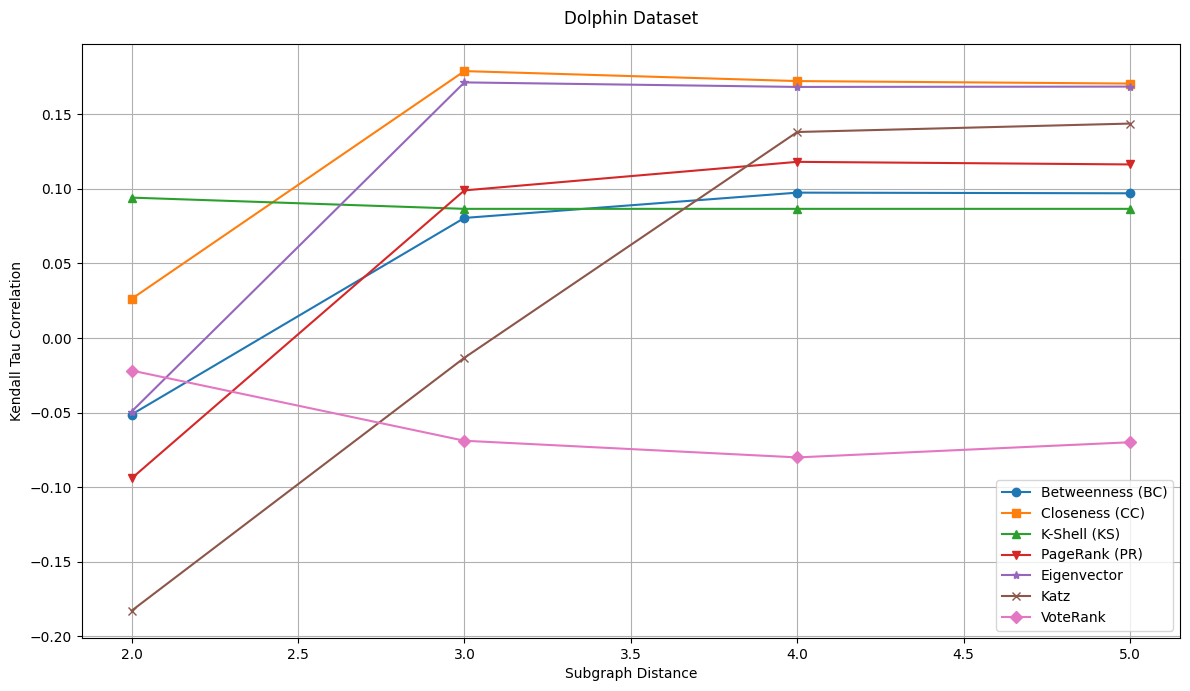

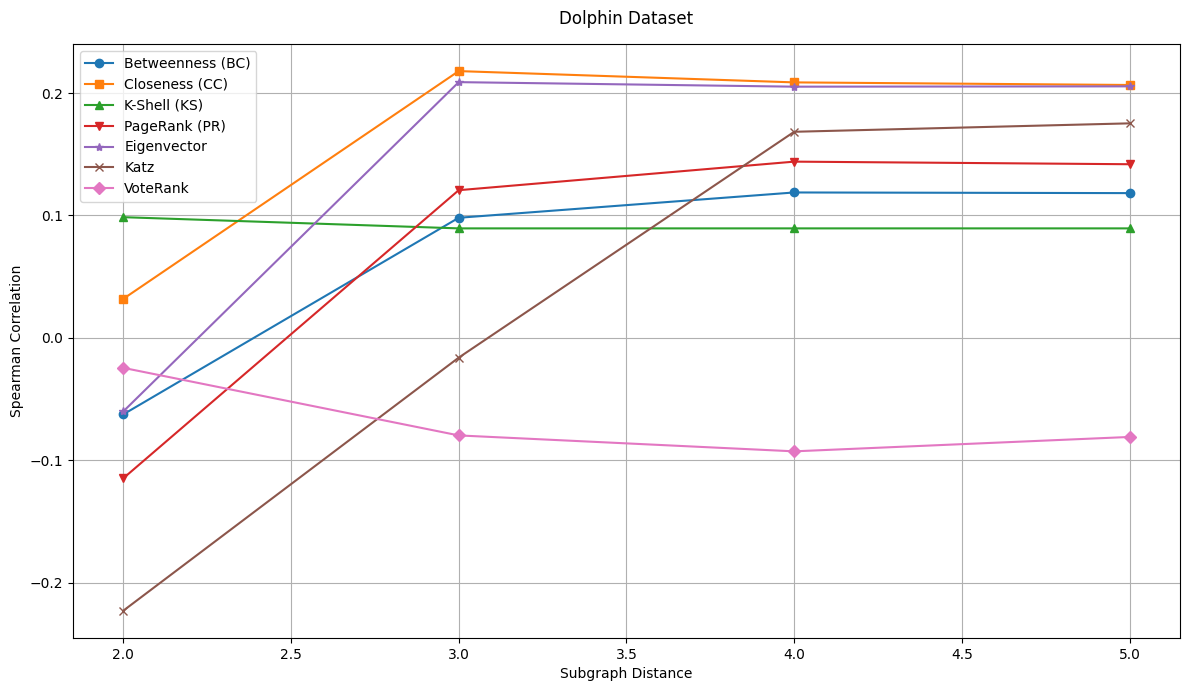

In [ ]:
# Convert results to DataFrame
kendall_df = pd.DataFrame(kendall_results)
spearman_df = pd.DataFrame(spearman_results)

#kendall tau correlation
plt.figure(figsize=(12, 7))
plt.plot(kendall_df["Distance"], kendall_df["Betweenness"], marker="o", label="Betweenness (BC)")
plt.plot(kendall_df["Distance"], kendall_df["Closeness"], marker="s", label="Closeness (CC)")
plt.plot(kendall_df["Distance"], kendall_df["K-Shell"], marker="^", label="K-Shell (KS)")
plt.plot(kendall_df["Distance"], kendall_df["PageRank"], marker="v", label="PageRank (PR)")
plt.plot(kendall_df["Distance"], kendall_df["Eigenvector"], marker="*", label="Eigenvector")
plt.plot(kendall_df["Distance"], kendall_df["Katz"], marker="x", label="Katz")
plt.plot(kendall_df["Distance"], kendall_df["VoteRank"], marker="D", label="VoteRank")
plt.xlabel("Subgraph Distance")
plt.ylabel("Kendall Tau Correlation")
#plt.title("Kendall Tau Correlation vs Subgraph Distance")
plt.title("Dolphin Dataset", fontsize=12, y=1.02)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


# Plot Spearman Correlation
plt.figure(figsize=(12, 7))
plt.plot(spearman_df["Distance"], spearman_df["Betweenness"], marker="o", label="Betweenness (BC)")
plt.plot(spearman_df["Distance"], spearman_df["Closeness"], marker="s", label="Closeness (CC)")
plt.plot(spearman_df["Distance"], spearman_df["K-Shell"], marker="^", label="K-Shell (KS)")
plt.plot(spearman_df["Distance"], spearman_df["PageRank"], marker="v", label="PageRank (PR)")
plt.plot(spearman_df["Distance"], spearman_df["Eigenvector"], marker="*", label="Eigenvector")
plt.plot(spearman_df["Distance"], spearman_df["Katz"], marker="x", label="Katz")
plt.plot(spearman_df["Distance"], spearman_df["VoteRank"], marker="D", label="VoteRank")
plt.xlabel("Subgraph Distance")
plt.ylabel("Spearman Correlation")
#plt.title("Spearman Correlation vs Subgraph Distance")
plt.title("Dolphin Dataset", fontsize=12, y=1.02)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()